## Codes 
**Autors:**  Amador Jesus, Hernández Roberto, Hernández Belinda, Ramos Sarai 

## Installation

In [1]:
! pip uninstall -y hammindist
! pip install git+https://github.com/JesusAmador25/hammindist

Found existing installation: hammindist 0.1.0
Uninstalling hammindist-0.1.0:
  Successfully uninstalled hammindist-0.1.0
  Cloning https://github.com/JesusAmador25/hammindist to /tmp/pip-req-build-04uk07as
  Running command git clone --filter=blob:none --quiet https://github.com/JesusAmador25/hammindist /tmp/pip-req-build-04uk07as
  Resolved https://github.com/JesusAmador25/hammindist to commit dfff041664e82c3bea78c0f2499c362bec40be34
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hammindist: filename=hammindist-0.1.0-py3-none-any.whl size=23450 sha256=73b06fcd71c0ee42034f49330b63ac9e0f5851fa7103cbe707ac476cd3a5b098
  Stored in directory: /tmp/pip-ephem-wheel-cache-mjfrjsef/wheels/02/ed/55/306ab71849d69bf50230ec34a248fae4e350d2e81bc2328f52
Successfully built hammindist


In [2]:
import hammindist.functions as hd


# Instance

The instance is a binary tuple space of length n. The set of all binary tuples of length n has $2^n$ elements, which we represent as vertices of a graph and like tuples.

In [3]:
H = hd.HammingTupla(4,2)
H.__repr__

<bound method HammingTupla.__repr__ of HammingTupla(lenght = 4, distance = 2)>

We implement two methods to generate instances```get_instances_complete()``` and ```get_instances_restricted()```:

In [4]:
complete   = list(H.get_instances_complete())
restricted = list(H.get_instances_restricted())

print(f"Complete tuples  (all 2^{H.lenght}): {len(complete)}")
print(f"Restricted tuples (weight ≤ {H.distance}): {len(restricted)}")

Complete tuples  (all 2^4): 16
Restricted tuples (weight ≤ 2): 11


```HammingTupla.hamming_distance(X, Y)``` is a static method to calculate the hamming distance between 2 elements, so it can be called directly on the class without creating an instance.

In [5]:
X = (1, 0, 1, 0)
Y = (0, 0, 1, 1)

d = hd.HammingTupla.hamming_distance(X, Y)
print(f"X = {X}")
print(f"Y = {Y}")
print(f"Hamming distance d(X, Y) = {d}")

X = (1, 0, 1, 0)
Y = (0, 0, 1, 1)
Hamming distance d(X, Y) = 2


For drawing the Hamming Graph, we implement ```draw()```. 

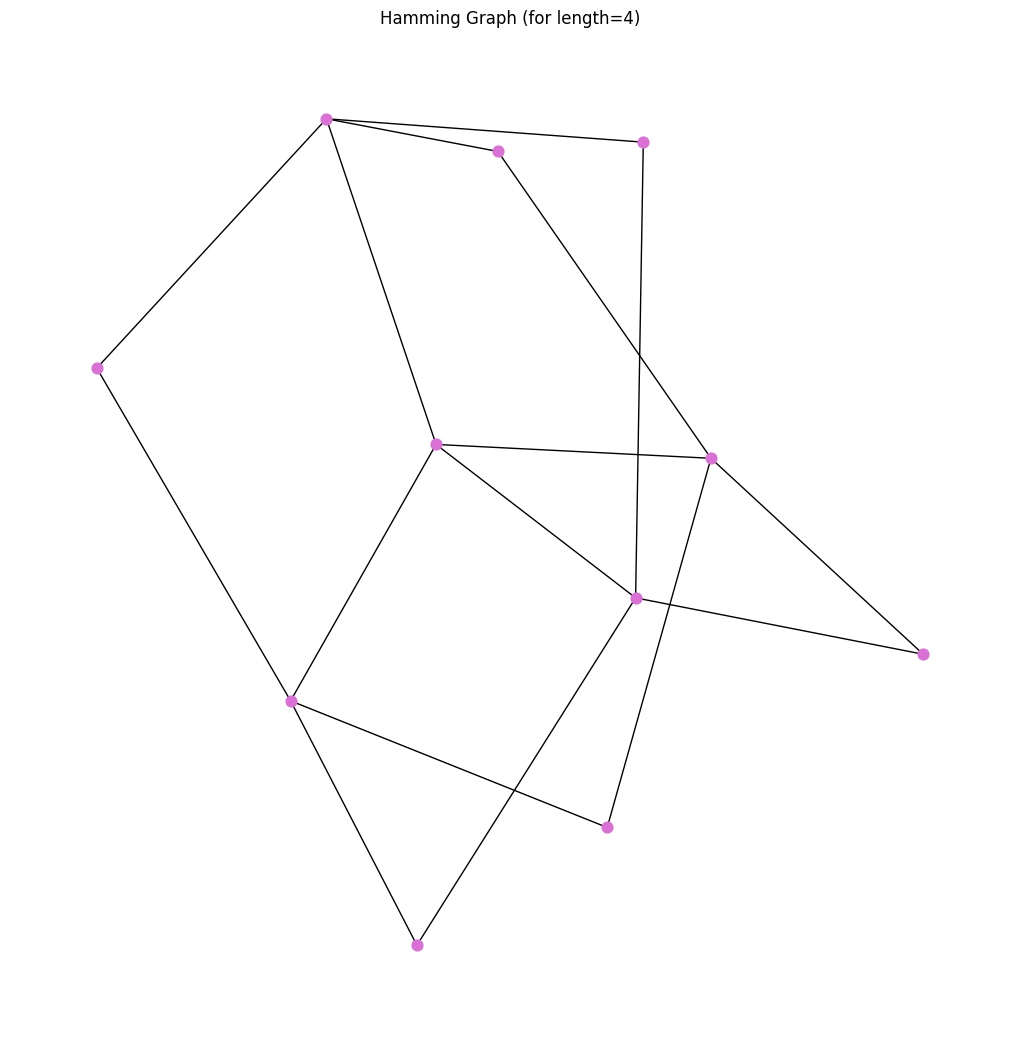

In [6]:
H.draw()

## Backtracking functions

When building the code incrementally, we need to check whether a new codeword can be added without violating the minimum distance constraint. ```is_valid_set``` checks that the new code is at distance $≥d$ from every codeword already in the set.

In [7]:
# Current partial code with min distance 2
current = [(0,0,0,0), (1,1,0,0)]

candidate_a = (1,0,0,0)  # does it fit?
candidate_b = (0,1,1,1)  # does it fit?

print(f"Can we add {candidate_a}? {hd.is_valid_set(current, candidate_a, 2)}")
print(f"Can we add {candidate_b}? {hd.is_valid_set(current, candidate_b, 2)}")

Can we add (1, 0, 0, 0)? False
Can we add (0, 1, 1, 1)? True


We use 2 classical upper bounds to prune the backtracking tree early, once we know no branch can beat the current best, we skip it.

* ```sphere_packing_bound```: Each codeword "occupies" a Hamming ball of radius $t = \lfloor(d-1)/2\rfloor$. Since balls around distinct codewords are disjoint, their total volume cannot exceed the full space $2^n$
* ```plotkin_bound```: Count the total pairwise distance of a code in two ways: from below, each of the $\binom{M}{2}$ pairs contributes at least d; from above, each bit position contributes at most $M^2/4$ differing pairs. Solving for M gives:
$A(n,d) \leq 2\left\lfloor \frac{d}{2d - n} \right\rfloor \quad \text{ when } 2d > n \quad \text{ then } A(n,d)≤2⌊2d−nd​⌋$. When $2d\leq n$ the bound does not apply and returns $\infty$.

So, we take the minimum of them with ```upper_bound```.

In [8]:
# Compare bounds for several (n, d) pairs
configs = [(7, 3), (8, 6), (10, 4), (25, 15)]

print(f"{'n':>4}  {'d':>4}  {'Sphere-packing':>16}  {'Plotkin':>10}  {'Tightest':>10}")
print("-" * 52)
for n, d in configs:
    sp = hd.sphere_packing_bound(n, d)
    pl = hd.plotkin_bound(n, d)
    ub = hd.upper_bound(n, d)
    pl_str = str(pl) if pl != float('inf') else "∞"
    print(f"{n:>4}  {d:>4}  {sp:>16}  {pl_str:>10}  {ub:>10}")

   n     d    Sphere-packing     Plotkin    Tightest
----------------------------------------------------
   7     3                16           ∞          16
   8     6                 6           2           2
  10     4                93           ∞          93
  25    15                46           6           6


```max_set``` finds the largest subset of a given list of codes such that all pairs are at distance $\geq d$. It uses backtracking with pruning: if the remaining candidates can no longer improve the current best solution, the branch is abandoned immediately.
The pruning condition is:
$|\text{current}| + |\text{remaining}| \leq |\text{best so far}| \implies \text{prune}$

In [11]:
all_codes = list(hd.HammingTupla(7, 4).get_instances_complete())

best = hd.max_set(all_codes, min_distance=4)
print(f"Optimal code for n=6, d=4:")
print(f"  Size : {len(best)}  ")
for cw in best:
    print(f"  {cw}")

Optimal code for n=6, d=4:
  Size : 8  
  (0, 0, 0, 0, 0, 0, 0)
  (0, 0, 0, 1, 1, 1, 1)
  (0, 1, 1, 0, 0, 1, 1)
  (0, 1, 1, 1, 1, 0, 0)
  (1, 0, 1, 0, 1, 0, 1)
  (1, 0, 1, 1, 0, 1, 0)
  (1, 1, 0, 0, 1, 1, 0)
  (1, 1, 0, 1, 0, 0, 1)


```max_set_bounded``` improves upon ```max_set``` by:

* Early termination: once the current set reaches the upper bound A(n,d), no larger code is possible then the branch is accepted and search stops.

In [12]:
best_bounded = hd.max_set_bounded(length=7, min_distance=4)
print(f"Optimal code for n=7, d=4:")
print(f"  Size : {len(best_bounded)}  (A(7,4) = 8 — Hamming code)")
for cw in best_bounded:
    print(f"  {cw}")

Optimal code for n=7, d=4:
  Size : 8  (A(7,4) = 8 — Hamming code)
  (0, 0, 0, 0, 0, 0, 0)
  (0, 0, 0, 1, 1, 1, 1)
  (0, 1, 1, 0, 0, 1, 1)
  (0, 1, 1, 1, 1, 0, 0)
  (1, 0, 1, 0, 1, 0, 1)
  (1, 0, 1, 1, 0, 1, 0)
  (1, 1, 0, 0, 1, 1, 0)
  (1, 1, 0, 1, 0, 0, 1)


# Graph-Based Maximum Clique Search

The problem of finding $A(n,d)$ the largest binary code of length n with minimum distance d is equivalent to finding a maximum clique in a graph.

```build_adjacency_bitsets``` this function constructs the graph G(n,d) where vertices are binary words of length n and edges connect pairs at Hamming distance $\geq d$.
Parity reduction: when d is even, only words with even parity (even number of 1-bits) need to be considered. This halves the number of vertices without losing any optimal code.
The graph is stored as a list of integer bitsets adj, where adj[i] has bit j set if vertices i and j are adjacent.

``` greedy_color``` assigns colors to vertices so that no two adjacent vertices share a color. 

```greedy_initial_clique``` before the exact search begins, we find a large clique greedily to establish a good lower bound. This means the exact algorithm can prune more branches from the start. The heuristic is: sort vertices by degree (highest degree first), then greedily add each vertex to the clique if it is adjacent to all current members.

```max_clique_tomita``` It implements Tomita's branch-and-bound method, which maintains three sets at each node of the search tree: (Current clique being built (R), Candidates: vertices adjacent to all of R not yet decided (P), Excluded: vertices adjacent to all of R, already processed (X))

```A(n, d)``` ties everything together: it builds the graph, runs Tomita's algorithm, decodes the clique from bitset back to binary words, and reports the result.

In [16]:
hd.A(7,3)


Building an adjacence graph (distance ≥ 3) forn=7...
Nodes: 128 (parity reduction: False)
A(7,3) = 16  (tiempo: 0.69 segundos)
Código encontrado (palabras en decimal):
[0, 7, 25, 30, 42, 45, 51, 52, 75, 76, 82, 85, 97, 102, 120, 127]


(16, [0, 7, 25, 30, 42, 45, 51, 52, 75, 76, 82, 85, 97, 102, 120, 127])

In [18]:
hd.A(12,8)

Building an adjacence graph (distance ≥ 8) forn=12...
Nodes: 2048 (parity reduction: True)
A(12,8) = 4  (tiempo: 0.04 segundos)
Código encontrado (palabras en decimal):
[0, 255, 3855, 4080]


(4, [0, 255, 3855, 4080])

## Heuristic algorithm

For larger instances we use heuristic methods that trade guaranteed optimality for speed.

```heuristic```: fast, gives a lower bound in seconds.

```simulated_annealing```: slower but finds near-optimal codes by escaping local optima.

Both return a *valid* code (all pairwise distances $\geq d$), so their output is always a lower bound on A(n,d).

In [19]:
code = hd.heuristic(9, 4, iterations=9800, seed=666)
print(f"A(9,4) >= {len(code)}")

A(9,4) >= 20


In [ ]:
code = hd.heuristic(10, 4, iterations=10000, seed=999)
print(f"A(10,4) >= {len(code)}")

In [ ]:
code = hd.simulated_annealing(9, 4, iterations=5000,T_start=1.0, T_end=0.01, tabu_tenure=20, max_perturbation=3,seed= 555)
len(code)

20

In [ ]:
code = hd.simulated_annealing(10, 4,iterations=100,tabu_tenure=45,max_perturbation=8, seed=312)
len(code)

34